In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [2]:
synapsida = pd.read_csv('points_Synapsida_niche.csv', sep=';')
synapsida.head()

,accepted_name,accepted_rank,early_interval,late_interval,max_ma,min_ma,time_bins,age,Rotated Longitude,Rotated latitude,group,niche_adequability
0,Abajudon kaayai,species,Wordian,Capitanian,268.8,259.9,Wordian,265,-56.95375,-1.203179,Dicynodontia,0.209761
1,Abajudon kaayai,species,Wordian,Capitanian,268.8,259.9,Wordian,265,-56.95375,-1.203179,Dicynodontia,0.209761
2,Abajudon kaayai,species,Wordian,Capitanian,268.8,259.9,Wordian,265,-56.95375,-1.203179,Dicynodontia,0.209761
3,Abajudon kaayai,species,Wordian,Capitanian,268.8,259.9,Wordian,265,-56.95375,-1.203179,Dicynodontia,0.209761
4,Abajudon kaayai,species,Wordian,Capitanian,268.8,259.9,Wordian,265,-56.95375,-1.203179,Dicynodontia,0.209761


In [38]:
synapsida.describe()

,max_ma,min_ma,age,Rotated Longitude,Rotated latitude,niche_adequability
count,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1327.000000
mean,254.628901,246.955666,250.077612,-43.590576,-5.111178,0.161312
std,10.706562,13.839763,11.585379,34.431085,26.088152,0.195572
min,215.560000,201.300000,215.000000,-76.786580,-50.240640,0.015022
25%,252.170000,247.200000,250.000000,-62.751640,-19.334250,0.048410
50%,259.510000,252.170000,255.000000,-60.850790,-14.724960,0.053002
75%,259.900000,254.170000,255.000000,-49.043510,0.077961,0.223840
max,298.900000,266.900000,266.000000,61.210970,126.127300,0.832678


In [3]:
# Remove all ranks above genus
synapsida_filtered = synapsida[synapsida['accepted_rank'].str.contains('genus|species', case=False, na=False)]

# Cheecking that that worked
synapsida_filtered[synapsida_filtered['accepted_rank'] =="clade"]

,accepted_name,accepted_rank,early_interval,late_interval,max_ma,min_ma,time_bins,age,Rotated Longitude,Rotated latitude,group,niche_adequability


In [4]:
# Checking for null values
synapsida_filtered.isna().sum()

accepted_name           0
accepted_rank           0
early_interval          0
late_interval         740
max_ma                  0
min_ma                  0
time_bins               0
age                     0
Rotated Longitude       0
Rotated latitude        0
group                   0
niche_adequability      9
dtype: int64

In [5]:
# Imputing empty 'late_interval' values with the 'early_interval' value to remove empty cells
synapsida_filtered['late_interval'] = synapsida_filtered['late_interval'].fillna(synapsida_filtered['early_interval'])

# Checking that that worked
synapsida_filtered.isna().sum()

<ipython-input-5-0da8727b267b>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  synapsida_filtered['late_interval'] = synapsida_filtered['late_interval'].fillna(synapsida_filtered['early_interval'])


accepted_name         0
accepted_rank         0
early_interval        0
late_interval         0
max_ma                0
min_ma                0
time_bins             0
age                   0
Rotated Longitude     0
Rotated latitude      0
group                 0
niche_adequability    9
dtype: int64

In [6]:
# Dropping rows with nulls in niche_adequability for now (until Arielli is done!)
synapsida_filtered.dropna(subset=['niche_adequability'], inplace=True)

# Checking that that worked
synapsida_filtered.isna().sum()

<ipython-input-6-b0d5689678a4>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  synapsida_filtered.dropna(subset=['niche_adequability'], inplace=True)


accepted_name         0
accepted_rank         0
early_interval        0
late_interval         0
max_ma                0
min_ma                0
time_bins             0
age                   0
Rotated Longitude     0
Rotated latitude      0
group                 0
niche_adequability    0
dtype: int64

In [7]:
synapsida_filtered.describe()

,max_ma,min_ma,age,Rotated Longitude,Rotated latitude,niche_adequability
count,1104.000000,1104.00000,1104.000000,1104.000000,1104.000000,1104.000000
mean,255.498350,248.07952,251.014493,-45.668762,-5.853830,0.149639
std,9.808756,12.66749,10.657180,33.434650,22.615332,0.192048
min,215.560000,201.30000,215.000000,-76.786580,-50.240640,0.015022
25%,252.170000,247.20000,250.000000,-62.751640,-19.334250,0.048410
50%,259.510000,252.17000,255.000000,-60.850790,-14.724960,0.048737
75%,259.900000,254.17000,255.000000,-49.980750,0.077961,0.124715
max,298.900000,266.90000,265.000000,61.210970,81.605770,0.802404


In [8]:
synapsida_filtered.head()

,accepted_name,accepted_rank,early_interval,late_interval,max_ma,min_ma,time_bins,age,Rotated Longitude,Rotated latitude,group,niche_adequability
0,Abajudon kaayai,species,Wordian,Capitanian,268.8,259.9,Wordian,265,-56.95375,-1.203179,Dicynodontia,0.209761
1,Abajudon kaayai,species,Wordian,Capitanian,268.8,259.9,Wordian,265,-56.95375,-1.203179,Dicynodontia,0.209761
2,Abajudon kaayai,species,Wordian,Capitanian,268.8,259.9,Wordian,265,-56.95375,-1.203179,Dicynodontia,0.209761
3,Abajudon kaayai,species,Wordian,Capitanian,268.8,259.9,Wordian,265,-56.95375,-1.203179,Dicynodontia,0.209761
4,Abajudon kaayai,species,Wordian,Capitanian,268.8,259.9,Wordian,265,-56.95375,-1.203179,Dicynodontia,0.209761


In [9]:
# Splitting the 'accepted_rank' column into genus and species columns (if available) 

# Create a new column 'species' filled with empty strings
synapsida_filtered_split = synapsida_filtered
synapsida_filtered_split['species'] = ''

# Loop through each row in the dataframe
for index, row in synapsida_filtered_split.iterrows():
    # Split the 'names' value into words
    accepted_name_split = row['accepted_name'].split()
    
    # If there are two words, update 'names' and 'name 2'
    if len(accepted_name_split) == 2:
        synapsida_filtered_split.at[index, 'accepted_name'] = accepted_name_split[0]
        synapsida_filtered_split.at[index, 'species'] = accepted_name_split[1]

synapsida_filtered_split.head()

<ipython-input-9-7ea512fa8cb6>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  synapsida_filtered_split['species'] = ''


,accepted_name,accepted_rank,early_interval,late_interval,max_ma,min_ma,time_bins,age,Rotated Longitude,Rotated latitude,group,niche_adequability,species
0,Abajudon,species,Wordian,Capitanian,268.8,259.9,Wordian,265,-56.95375,-1.203179,Dicynodontia,0.209761,kaayai
1,Abajudon,species,Wordian,Capitanian,268.8,259.9,Wordian,265,-56.95375,-1.203179,Dicynodontia,0.209761,kaayai
2,Abajudon,species,Wordian,Capitanian,268.8,259.9,Wordian,265,-56.95375,-1.203179,Dicynodontia,0.209761,kaayai
3,Abajudon,species,Wordian,Capitanian,268.8,259.9,Wordian,265,-56.95375,-1.203179,Dicynodontia,0.209761,kaayai
4,Abajudon,species,Wordian,Capitanian,268.8,259.9,Wordian,265,-56.95375,-1.203179,Dicynodontia,0.209761,kaayai


In [10]:
# Rename accepted_name column, which now only contains genus to 'genus'
synapsida2 = synapsida_filtered_split.rename(columns={'accepted_name':'genus'})
synapsida2.head()

,genus,accepted_rank,early_interval,late_interval,max_ma,min_ma,time_bins,age,Rotated Longitude,Rotated latitude,group,niche_adequability,species
0,Abajudon,species,Wordian,Capitanian,268.8,259.9,Wordian,265,-56.95375,-1.203179,Dicynodontia,0.209761,kaayai
1,Abajudon,species,Wordian,Capitanian,268.8,259.9,Wordian,265,-56.95375,-1.203179,Dicynodontia,0.209761,kaayai
2,Abajudon,species,Wordian,Capitanian,268.8,259.9,Wordian,265,-56.95375,-1.203179,Dicynodontia,0.209761,kaayai
3,Abajudon,species,Wordian,Capitanian,268.8,259.9,Wordian,265,-56.95375,-1.203179,Dicynodontia,0.209761,kaayai
4,Abajudon,species,Wordian,Capitanian,268.8,259.9,Wordian,265,-56.95375,-1.203179,Dicynodontia,0.209761,kaayai


## Ages EDA
Finding median, min, and max for max_ma, min_ma
Creating mean_ma column for middle of each occurrence's age range
Then plotting max_ma, min_ma, mean_ma distributions

In [11]:
synapsida2.describe()   

,max_ma,min_ma,age,Rotated Longitude,Rotated latitude,niche_adequability
count,1104.000000,1104.00000,1104.000000,1104.000000,1104.000000,1104.000000
mean,255.498350,248.07952,251.014493,-45.668762,-5.853830,0.149639
std,9.808756,12.66749,10.657180,33.434650,22.615332,0.192048
min,215.560000,201.30000,215.000000,-76.786580,-50.240640,0.015022
25%,252.170000,247.20000,250.000000,-62.751640,-19.334250,0.048410
50%,259.510000,252.17000,255.000000,-60.850790,-14.724960,0.048737
75%,259.900000,254.17000,255.000000,-49.980750,0.077961,0.124715
max,298.900000,266.90000,265.000000,61.210970,81.605770,0.802404


In [12]:
# Creating mean age values column for each row
synapsida2['mean_age'] = (synapsida2['max_ma'] + synapsida2['min_ma']) / 2
synapsida2.head()

,genus,accepted_rank,early_interval,late_interval,max_ma,min_ma,time_bins,age,Rotated Longitude,Rotated latitude,group,niche_adequability,species,mean_age
0,Abajudon,species,Wordian,Capitanian,268.8,259.9,Wordian,265,-56.95375,-1.203179,Dicynodontia,0.209761,kaayai,264.35
1,Abajudon,species,Wordian,Capitanian,268.8,259.9,Wordian,265,-56.95375,-1.203179,Dicynodontia,0.209761,kaayai,264.35
2,Abajudon,species,Wordian,Capitanian,268.8,259.9,Wordian,265,-56.95375,-1.203179,Dicynodontia,0.209761,kaayai,264.35
3,Abajudon,species,Wordian,Capitanian,268.8,259.9,Wordian,265,-56.95375,-1.203179,Dicynodontia,0.209761,kaayai,264.35
4,Abajudon,species,Wordian,Capitanian,268.8,259.9,Wordian,265,-56.95375,-1.203179,Dicynodontia,0.209761,kaayai,264.35


In [13]:
lad_frequency = synapsida2['min_ma'].value_counts()
fad_frequency = synapsida2['max_ma'].value_counts()
print(lad_frequency)
print(fad_frequency)

254.170    261
254.140    156
251.902    150
252.170    117
247.200     94
237.000     68
228.000     61
208.500     55
252.300     32
259.510     25
251.200     21
264.280     13
259.900     10
265.000     10
256.800     10
201.300      9
266.900      5
265.100      2
212.000      2
235.000      1
221.500      1
232.000      1
Name: min_ma, dtype: int64
259.900    360
259.510    316
252.170     95
242.000     73
237.000     61
228.000     48
268.000     34
264.280     21
254.170     17
266.900     16
251.200     15
247.200     12
268.800     10
273.010      7
251.902      4
276.500      4
259.000      4
272.300      2
215.560      2
298.900      1
235.000      1
232.000      1
Name: max_ma, dtype: int64


In [28]:
# Scatterplot function

def scatter(column_name):
    frequency = synapsida2[column_name].value_counts()

    # Create figure and axes objects explicitly
    fig, ax = plt.subplots(figsize=(12, 8))  # Increased figure size
    
    # Set figure facecolor to white
    fig.patch.set_facecolor('white')    
    
    sns.scatterplot(x=frequency.index, y=frequency.values)
    plt.title("Frequency of " + column_name)
    plt.xlabel(column_name)
    plt.ylabel("Frequency")

    # Dynamically determine x_min and x_max
    x_min = math.floor(min(frequency.index))
    x_max = math.ceil(max(frequency.index))

    # Ensure x_min and x_max are multiples of 5
    x_min = x_min - (x_min % 5)
    x_max = x_max + (5 - x_max % 5)

    # Create ticks and labels
    x_ticks = np.arange(x_min, x_max + 1, 1)  # Ticks for every 1
    x_labels = [str(x) if x % 5 == 0 else '' for x in x_ticks]  # Labels for every 5

    plt.xticks(x_ticks, x_labels)
    plt.xlim(x_min, x_max)

    plt.savefig(f'eda_images/{column_name}_scatter.png', dpi=300)
    plt.show()
    plt.close()

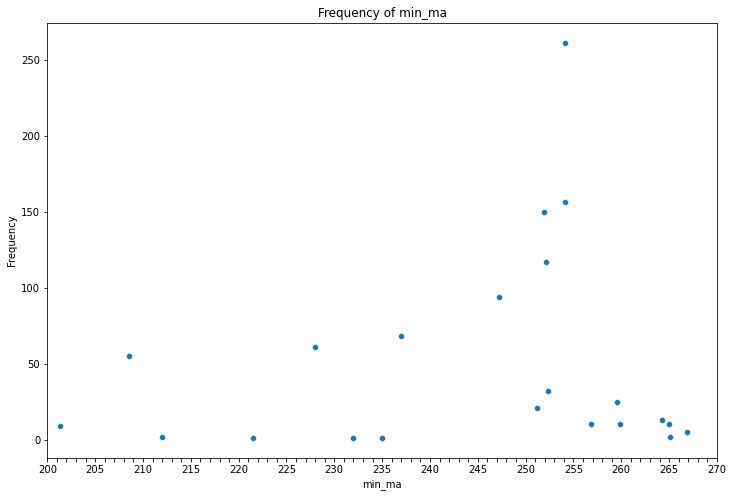

In [29]:
scatter('min_ma')


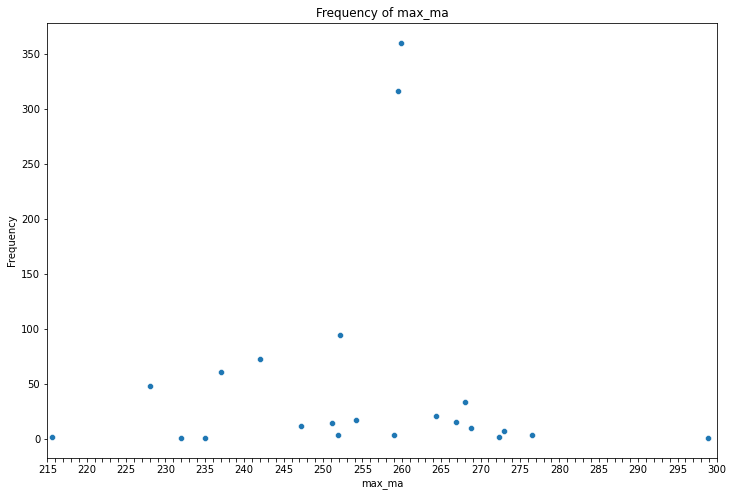

In [30]:
scatter('max_ma')

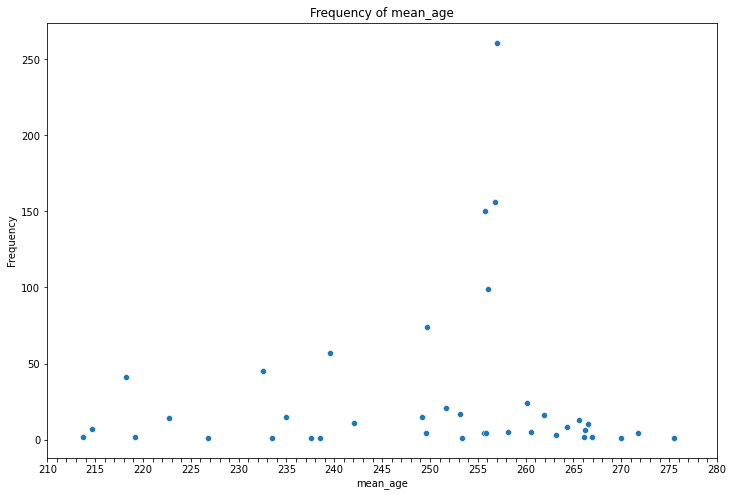

In [31]:
scatter('mean_age')

In [56]:
# Creating custom function for histogram w/ flexible number of bins

def flexible_histogram(column_name, bin_size=5):
    # Get the data
    data = synapsida2[column_name]

    # Create figure and axes objects explicitly
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Set figure facecolor to white
    fig.patch.set_facecolor('white')
    
    # Determine the range for the bins
    min_val = bin_size * math.floor(data.min() / bin_size)
    max_val = bin_size * math.ceil(data.max() / bin_size)
    bins = list(range(min_val, max_val + bin_size + 1, bin_size))

    # Plot the histogram
    n, bins, patches = ax.hist(data, bins=bins, edgecolor='black', align='left')
    
    # Add horizontal line at y=10
    ax.axhline(y=10, color='r', linestyle='--', linewidth=2)
    
    # Set title and labels
    ax.set_title(f"Distribution of {column_name}", fontsize=16, pad=20)
    ax.set_xlabel(column_name, fontsize=12, labelpad=10)
    ax.set_ylabel("Frequency", fontsize=12, labelpad=10)
    
    # Invert x-axis
    ax.set_xlim(max_val + bin_size, min_val)
    
    # Set x-ticks
    ax.set_xticks(bins[:-1] + bin_size/2)  # Center x-ticks in the middle of each bar
    ax.set_xticklabels([f'{x:.0f}-{x+bin_size-1:.0f}' for x in bins[:-1]], rotation=45, ha='right')

    # Add grid lines for better readability
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Adjust layout to prevent cutting off labels
    plt.tight_layout()

    # Save the figure with a higher dpi and bbox_inches='tight' to include all elements
    plt.savefig(f'eda_images/{column_name}_histogram_bin{bin_size}.png', dpi=300, bbox_inches='tight', facecolor='white')
    
    plt.show()
    plt.close()



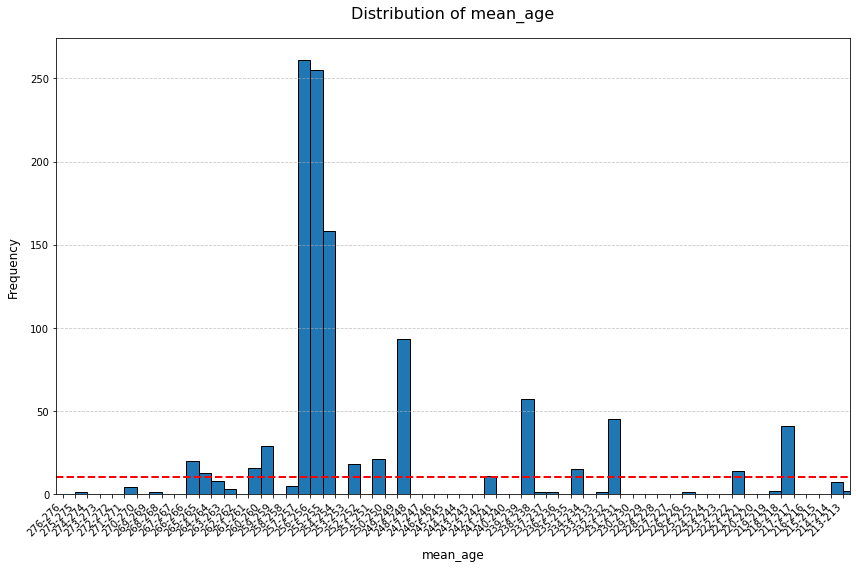

In [58]:
flexible_histogram('mean_age', 1)

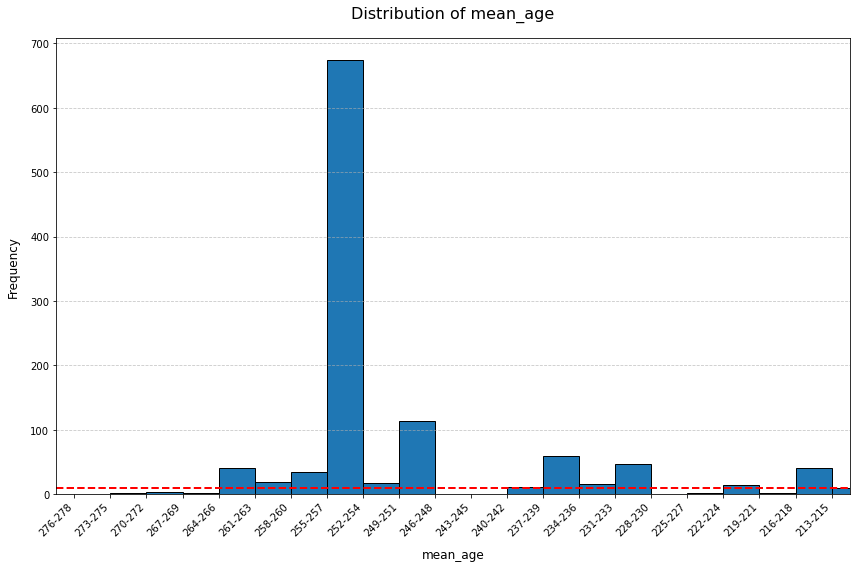

In [59]:
flexible_histogram('mean_age', 3)

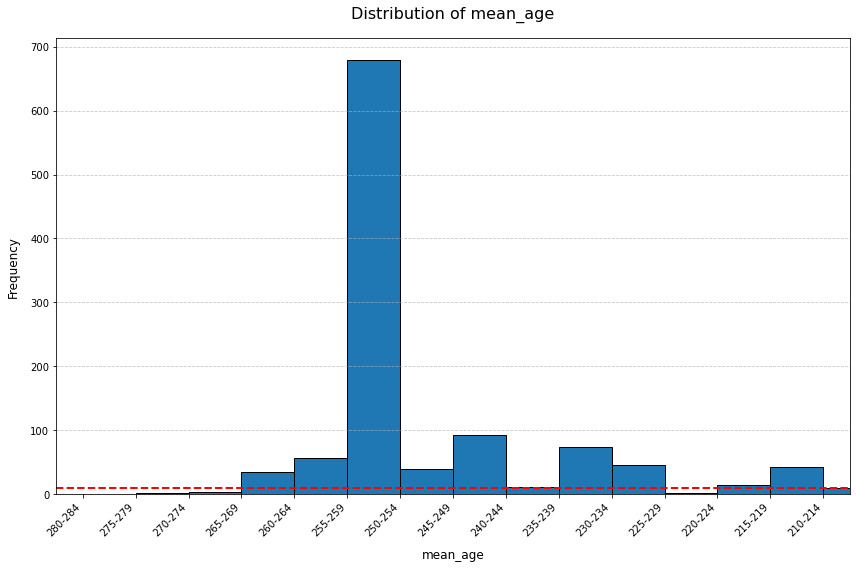

In [57]:
flexible_histogram('mean_age', 5)